     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 958.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 4.8 MB/s eta 0:00:00
Segmentation model loaded.
Chunk 0: 914 files
Chunk 1: 915 files
Combined total: 1829 files
[0/1829] pre-pass elapsed: 0.0 min
[200/1829] pre-pass elapsed: 0.4 min
[400/1829] pre-pass elapsed: 0.8 min
[600/1829] pre-pass elapsed: 1.2 min
[1000/1829] pre-pass elapsed: 1.7 min
[1200/1829] pre-pass elapsed: 2.0 min
[1400/1829] pre-pass elapsed: 2.3 min
Cases with detected tumor: 1251
Cases excluded (zero predicted tumor, likely seg misses): 0
Composite severity tertile thresholds: <0.2699 Slight | <0.3632 Mild | >= Severe
[0/1829] brats_BraTS2021_00006: nodes=212, label=Severe, elapsed=0.0 min
[100/1829] brats_BraTS2021_00293: nodes=198, label=Slight, elapsed=4.8 min
[200/1829] brats_BraTS2021_00568: nodes=213, label=Severe, elapsed=9.5 min
[300/1829] brats_Br

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


Epoch 10/100 | train_loss=0.4306 val_loss=0.3960 val_acc=0.8504
Epoch 20/100 | train_loss=0.3472 val_loss=0.3730 val_acc=0.8321
Epoch 30/100 | train_loss=0.2876 val_loss=0.4080 val_acc=0.8248
Epoch 40/100 | train_loss=0.2576 val_loss=0.3822 val_acc=0.8577
Epoch 50/100 | train_loss=0.2193 val_loss=0.3151 val_acc=0.8796
Epoch 60/100 | train_loss=0.2369 val_loss=0.3338 val_acc=0.8650
Epoch 70/100 | train_loss=0.1849 val_loss=0.3380 val_acc=0.8905
Epoch 80/100 | train_loss=0.2230 val_loss=0.3085 val_acc=0.8796
Epoch 90/100 | train_loss=0.1818 val_loss=0.8373 val_acc=0.8102
Epoch 100/100 | train_loss=0.1326 val_loss=0.4018 val_acc=0.8759
GAT training done in 4.7 min. Best val acc: 0.8978
True class: Slight
Predicted class: Slight
Top 5 important nodes: [ 48  60 207  15  63]


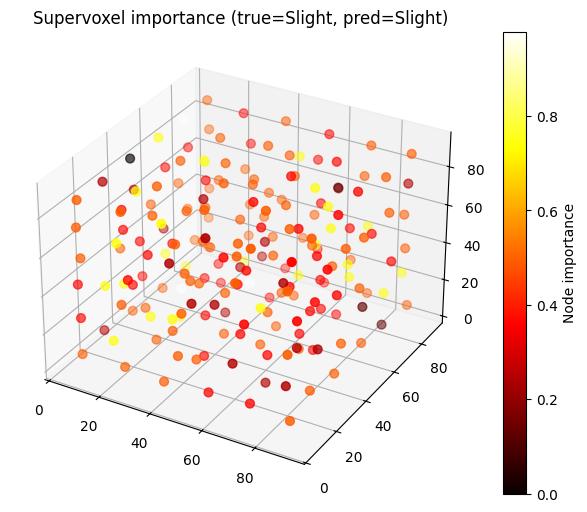

Accuracy: 0.9091 | Precision: 0.9000 | Recall: 0.8996 | F1: 0.8971


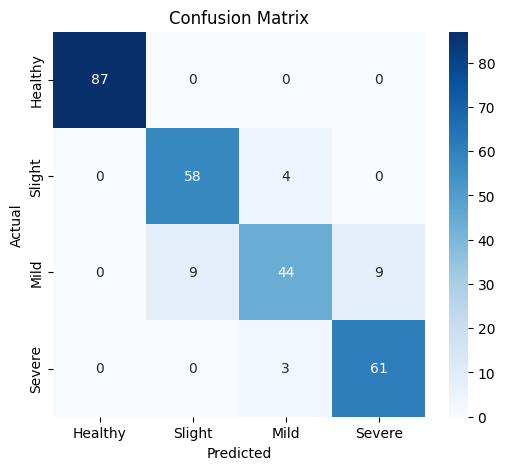

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


Edema: Dice=0.7464, HD95=4.3409
Enhancing: Dice=0.8132, HD95=3.4722
Necrotic: Dice=0.7996, HD95=3.4771
{
  "gat_classification": {
    "accuracy": 0.9090909090909091,
    "precision_macro": 0.899961327814708,
    "recall_macro": 0.8995715725806452,
    "f1_macro": 0.8971084073356208
  },
  "segmentation": {
    "Edema": {
      "dice": 0.7464448809623718,
      "hd95": 4.34085750579834
    },
    "Enhancing": {
      "dice": 0.8131785988807678,
      "hd95": 3.472158908843994
    },
    "Necrotic": {
      "dice": 0.7995829582214355,
      "hd95": 3.4770987033843994
    }
  },
  "severity_composite_thresholds": {
    "t1_slight": 0.2699039943399588,
    "t2_mild": 0.36319116901695414
  },
  "severity_weights": {
    "volume": 0.6,
    "necrotic_ratio": 0.25,
    "enhancing_ratio": 0.15
  },
  "graph_label_distribution": {
    "Healthy": 578,
    "Slight": 413,
    "Mild": 412,
    "Severe": 426
  },
  "skipped_ambiguous_cases": 0,
  "total_graphs": 1829,
  "supervoxels_per_graph": 200,

In [1]:
# ============================================================
# BLOCK 1 — Installs & imports
# ============================================================
!pip install -q torch-geometric scikit-image scipy scikit-learn seaborn monai

import os, glob, json, time, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from skimage.segmentation import slic
from scipy import ndimage
from scipy.stats import entropy as scipy_entropy
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)
from torch_geometric.data import Data, Dataset as PyGDataset
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool
from torch_geometric.explain import Explainer, GNNExplainer
from monai.networks.nets import UNet
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.transforms import AsDiscrete
from monai.data import decollate_batch
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", message=".*ground truth of class.*")
warnings.filterwarnings("ignore", message=".*prediction of class.*")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# BLOCK 2 — Load trained segmentation model (96^3 checkpoint)
# ============================================================
seg_model = UNet(
    spatial_dims=3, in_channels=4, out_channels=4,
    channels=(32, 64, 128, 256, 512), strides=(2, 2, 2, 2), num_res_units=2,
).to(device)

seg_model.load_state_dict(torch.load(
    "/kaggle/input/datasets/krishybrown/unet3d-checkpoint-full/best_unet3d.pth",
    map_location=device, weights_only=False))
seg_model.eval()
print("Segmentation model loaded.")

VOLUME_SHAPE = (96, 96, 96)   # must match TARGET_SIZE used to train seg_model


# ============================================================
# BLOCK 3 — Load both chunk datasets combined
# ============================================================
CHUNK0_DIR = "/kaggle/input/datasets/krishybrown/brats2021-ixi-chunk0/processed"
CHUNK1_DIR = "/kaggle/input/datasets/krishybrown/brats2021-ixi-chunk1/processed"

files_chunk0 = sorted(glob.glob(os.path.join(CHUNK0_DIR, "*.pt")))
files_chunk1 = sorted(glob.glob(os.path.join(CHUNK1_DIR, "*.pt")))
all_files = files_chunk0 + files_chunk1

print(f"Chunk 0: {len(files_chunk0)} files")
print(f"Chunk 1: {len(files_chunk1)} files")
print(f"Combined total: {len(all_files)} files")
assert len(all_files) > 0, "No files found — check CHUNK0_DIR / CHUNK1_DIR paths."

def load_sample(fpath):
    d = torch.load(fpath, weights_only=False)
    d["image"] = d["image"].float()
    d["label"] = d["label"].long()
    return d


# ============================================================
# BLOCK 4 — Phase 6: Tumor statistics
# ============================================================
def compute_tumor_stats(mask, voxel_spacing=(1.5, 1.5, 1.5)):
    tumor_mask = (mask > 0).astype(np.uint8)
    voxel_vol = np.prod(voxel_spacing)
    voxel_count = tumor_mask.sum()
    volume_mm3 = voxel_count * voxel_vol

    if voxel_count == 0:
        return {"volume_mm3": 0.0, "surface_area": 0.0, "sphericity": 0.0,
                "entropy": 0.0, "edema_ratio": 0.0, "enhancing_ratio": 0.0,
                "necrotic_ratio": 0.0}

    eroded = ndimage.binary_erosion(tumor_mask)
    surface_voxels = tumor_mask.astype(bool) & ~eroded
    surface_area = surface_voxels.sum() * (voxel_spacing[0] * voxel_spacing[1])
    sphericity = ((np.pi ** (1/3) * (6 * volume_mm3) ** (2/3)) / surface_area
                  if surface_area > 0 else 0.0)

    hist, _ = np.histogram(mask[tumor_mask.astype(bool)], bins=4, density=True)
    hist = hist[hist > 0]
    tex_entropy = scipy_entropy(hist)

    total = voxel_count
    return {
        "volume_mm3": float(volume_mm3), "surface_area": float(surface_area),
        "sphericity": float(np.clip(sphericity, 0, 1)), "entropy": float(tex_entropy),
        "edema_ratio": float((mask == 1).sum() / total),
        "enhancing_ratio": float((mask == 2).sum() / total),
        "necrotic_ratio": float((mask == 3).sum() / total),
    }


# ============================================================
# BLOCK 5 — Pre-pass: compute stats across glioma cases,
# build a COMPOSITE severity score (not volume-only)
# ============================================================
glioma_stats_list = []
seg_fail_count = 0
start_prepass = time.time()

for i, fpath in enumerate(all_files):
    sample = load_sample(fpath)
    if sample["source"] != "glioma":
        continue
    image = sample["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        pred = seg_model(image)
        pred_mask = torch.argmax(pred, dim=1)[0].cpu().numpy()
    stats = compute_tumor_stats(pred_mask)
    if stats["volume_mm3"] > 0:
        glioma_stats_list.append(stats)
    else:
        seg_fail_count += 1

    if i % 200 == 0:
        elapsed = (time.time() - start_prepass) / 60
        print(f"[{i}/{len(all_files)}] pre-pass elapsed: {elapsed:.1f} min")

print(f"Cases with detected tumor: {len(glioma_stats_list)}")
print(f"Cases excluded (zero predicted tumor, likely seg misses): {seg_fail_count}")

# Composite severity score: weighted combination of volume, necrotic ratio,
# enhancing ratio — a bigger tumor that's also more necrotic/enhancing
# is more clinically severe than raw volume alone would suggest.
volumes = np.array([s["volume_mm3"] for s in glioma_stats_list])
necrotic_ratios = np.array([s["necrotic_ratio"] for s in glioma_stats_list])
enhancing_ratios = np.array([s["enhancing_ratio"] for s in glioma_stats_list])

# Normalize volume to [0,1] via min-max (necrotic/enhancing ratios are already 0-1)
vol_norm = (volumes - volumes.min()) / (volumes.max() - volumes.min() + 1e-8)

composite_scores = 0.6 * vol_norm + 0.25 * necrotic_ratios + 0.15 * enhancing_ratios

t1, t2 = np.percentile(composite_scores, [33, 66])
print(f"Composite severity tertile thresholds: <{t1:.4f} Slight | <{t2:.4f} Mild | >= Severe")


# ============================================================
# BLOCK 6 — 4-class severity label function using composite score
# 0=Healthy, 1=Slight, 2=Mild, 3=Severe
# ============================================================
def compute_composite_score(stats, vol_min, vol_max):
    vol_norm = (stats["volume_mm3"] - vol_min) / (vol_max - vol_min + 1e-8)
    vol_norm = np.clip(vol_norm, 0, 1)
    return 0.6 * vol_norm + 0.25 * stats["necrotic_ratio"] + 0.15 * stats["enhancing_ratio"]

VOL_MIN, VOL_MAX = float(volumes.min()), float(volumes.max())

def severity_label_from_stats(stats, source, t1=t1, t2=t2):
    if source == "healthy":
        return 0
    if stats["volume_mm3"] == 0:
        return None   # excluded, not mislabeled healthy
    score = compute_composite_score(stats, VOL_MIN, VOL_MAX)
    if score < t1:
        return 1
    elif score < t2:
        return 2
    else:
        return 3

SEVERITY_LABELS = ["Healthy", "Slight", "Mild", "Severe"]


# ============================================================
# BLOCK 7 — Phase 7: Supervoxels + node features + edges
# FIXES: 200 supervoxels (was 100), normalized coordinates (was raw voxel coords)
# ============================================================
def generate_supervoxels(intensity_vol, n_segments=200, compactness=0.1):
    vol_norm = (intensity_vol - intensity_vol.min()) / (intensity_vol.max() - intensity_vol.min() + 1e-8)
    return slic(vol_norm, n_segments=n_segments, compactness=compactness, channel_axis=None, start_label=0)

def build_node_features(image_4ch, seg_mask, supervoxels, volume_shape=VOLUME_SHAPE):
    unique_ids = np.unique(supervoxels)
    node_features, node_coords = [], []
    for sid in unique_ids:
        region_mask = supervoxels == sid
        if region_mask.sum() == 0:
            continue
        coords = np.argwhere(region_mask)
        centroid = coords.mean(axis=0)
        feats = []
        for ch in range(image_4ch.shape[0]):
            vals = image_4ch[ch][region_mask]
            feats.extend([vals.mean(), vals.std()])
        tumor_prob = (seg_mask[region_mask] > 0).mean()
        hist, _ = np.histogram(image_4ch[1][region_mask], bins=8, density=True)
        hist = hist[hist > 0]
        tex_entropy = scipy_entropy(hist) if len(hist) > 0 else 0.0
        feats.extend([tumor_prob, tex_entropy])

        # FIX: normalize centroid to [0,1] instead of raw voxel positions
        norm_centroid = centroid / np.array(volume_shape)
        feats.extend(norm_centroid.tolist())

        node_features.append(feats)
        node_coords.append(centroid)   # raw coords kept only for 3D plotting
    return np.array(node_features, dtype=np.float32), np.array(node_coords, dtype=np.float32), unique_ids

def build_edges(node_coords, node_features, k=6):
    nbrs = NearestNeighbors(n_neighbors=min(k+1, len(node_coords))).fit(node_coords)
    distances, indices = nbrs.kneighbors(node_coords)
    edge_index, edge_attr = [], []
    for i in range(len(node_coords)):
        for j_idx in range(1, indices.shape[1]):
            j = indices[i, j_idx]
            dist = distances[i, j_idx]
            feat_sim = 1.0 / (1.0 + np.linalg.norm(node_features[i] - node_features[j]))
            weight = feat_sim / (1.0 + dist)
            edge_index.append([i, j]); edge_index.append([j, i])
            edge_attr.append([weight]); edge_attr.append([weight])
    return np.array(edge_index).T, np.array(edge_attr, dtype=np.float32)

def mri_to_graph(sample, seg_model, device, n_segments=200):
    image = sample["image"]
    image_np = image.numpy()
    with torch.no_grad():
        pred = seg_model(image.unsqueeze(0).to(device))
        pred_mask = torch.argmax(pred, dim=1)[0].cpu().numpy()

    stats = compute_tumor_stats(pred_mask)
    label = severity_label_from_stats(stats, sample["source"])
    if label is None:
        return None, stats

    supervoxels = generate_supervoxels(image_np[1], n_segments=n_segments)
    node_features, node_coords, _ = build_node_features(image_np, pred_mask, supervoxels)
    edge_index, edge_attr = build_edges(node_coords, node_features)

    graph = Data(
        x=torch.tensor(node_features, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        y=torch.tensor([label], dtype=torch.long),
        pos=torch.tensor(node_coords, dtype=torch.float),
    )
    return graph, stats


# ============================================================
# BLOCK 8 — Build & cache all graphs
# ============================================================
GRAPH_DIR = "/kaggle/working/graphs"
os.makedirs(GRAPH_DIR, exist_ok=True)

label_counts = {0: 0, 1: 0, 2: 0, 3: 0}
skipped = 0
start_time = time.time()

for i, fpath in enumerate(all_files):
    sample = load_sample(fpath)
    pid = sample["id"]
    graph, stats = mri_to_graph(sample, seg_model, device, n_segments=200)

    if graph is None:
        skipped += 1
        continue

    label_counts[graph.y.item()] += 1
    torch.save(graph, os.path.join(GRAPH_DIR, f"{pid}.pt"))

    if i % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"[{i}/{len(all_files)}] {pid}: nodes={graph.x.shape[0]}, "
              f"label={SEVERITY_LABELS[graph.y.item()]}, elapsed={elapsed:.1f} min")

print(f"Graph construction done in {(time.time()-start_time)/60:.1f} min.")
print(f"Skipped (ambiguous seg-miss cases): {skipped}")
print("Label distribution:", {SEVERITY_LABELS[k]: v for k, v in label_counts.items()})


# ============================================================
# BLOCK 9 — Graph dataset + STRATIFIED split (fix: was plain random_split)
# ============================================================
class GraphDataset(PyGDataset):
    def __init__(self, graph_files):
        super().__init__()
        self.graph_files = graph_files
    def len(self): return len(self.graph_files)
    def get(self, idx): return torch.load(self.graph_files[idx], weights_only=False)

graph_files = sorted(glob.glob(os.path.join(GRAPH_DIR, "*.pt")))
full_dataset = GraphDataset(graph_files)
print(f"Total graphs: {len(full_dataset)}")

# Load labels for stratification (fast — just reads the small y tensor per file)
all_labels_for_split = [torch.load(f, weights_only=False).y.item() for f in graph_files]

indices = list(range(len(graph_files)))
train_idx, temp_idx, train_y, temp_y = train_test_split(
    indices, all_labels_for_split, test_size=0.3, stratify=all_labels_for_split, random_state=42)
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_y, test_size=0.5, stratify=temp_y, random_state=42)

train_set = torch.utils.data.Subset(full_dataset, train_idx)
val_set = torch.utils.data.Subset(full_dataset, val_idx)
test_set = torch.utils.data.Subset(full_dataset, test_idx)

n_train, n_val, n_test = len(train_set), len(val_set), len(test_set)
print(f"train={n_train} val={n_val} test={n_test}")

# Confirm class balance across splits
for name, idxs, ys in [("train", train_idx, train_y), ("val", val_idx, None), ("test", test_idx, None)]:
    if ys is None:
        ys = [all_labels_for_split[i] for i in idxs]
    counts = {SEVERITY_LABELS[c]: ys.count(c) for c in range(4)}
    print(f"{name} distribution: {counts}")

train_loader = PyGDataLoader(train_set, batch_size=8, shuffle=True)
val_loader = PyGDataLoader(val_set, batch_size=8, shuffle=False)
test_loader = PyGDataLoader(test_set, batch_size=8, shuffle=False)


# ============================================================
# BLOCK 10 — Phase 8: GAT model
# FIXES: mean+max pooling concatenated (was mean-only, causing signal collapse)
# ============================================================
class TumorGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, num_classes=4, heads=4):
        super().__init__()
        self.gat1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.3)
        self.gat2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=0.3)
        self.gat3 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=0.3)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels * 2, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )
    def forward(self, x, edge_index, batch):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = self.gat3(x, edge_index)
        pooled_mean = global_mean_pool(x, batch)
        pooled_max = global_max_pool(x, batch)
        pooled = torch.cat([pooled_mean, pooled_max], dim=1)
        return self.classifier(pooled), x

in_channels = full_dataset[0].x.shape[1]
gat_model = TumorGAT(in_channels=in_channels, num_classes=4).to(device)
print(f"Node feature dimension: {in_channels}")


# ============================================================
# BLOCK 11 — GAT training with class-weighted loss (fix: was unweighted)
# ============================================================
class_counts = torch.tensor([label_counts[i] for i in range(4)], dtype=torch.float)
class_weights = (class_counts.sum() / (4 * class_counts)).to(device)
print("Class weights:", class_weights.cpu().numpy())

optimizer = torch.optim.Adam(gat_model.parameters(), lr=5e-4, weight_decay=1e-4)  # lowered from 1e-3
criterion = nn.CrossEntropyLoss(weight=class_weights)

def evaluate(loader):
    gat_model.eval()
    correct, total, loss_sum = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out, _ = gat_model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            loss_sum += loss.item() * batch.num_graphs
            correct += (out.argmax(dim=1) == batch.y).sum().item()
            total += batch.num_graphs
    return loss_sum / total, correct / total

EPOCHS_GAT = 100
best_val_acc = 0
start_time = time.time()

for epoch in range(EPOCHS_GAT):
    gat_model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out, _ = gat_model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    val_loss, val_acc = evaluate(val_loader)
    if (epoch + 1) % 10 == 0:
        train_loss_avg = total_loss / n_train
        print(f"Epoch {epoch+1}/{EPOCHS_GAT} | train_loss={train_loss_avg:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(gat_model.state_dict(), "/kaggle/working/best_gat.pth")

print(f"GAT training done in {(time.time()-start_time)/60:.1f} min. Best val acc: {best_val_acc:.4f}")


# ============================================================
# BLOCK 12 — Phase 9: Attention explainability
# ============================================================
gat_model.load_state_dict(torch.load("/kaggle/working/best_gat.pth", weights_only=False))
gat_model.eval()

class TumorGATWithAttention(TumorGAT):
    def forward(self, x, edge_index, batch):
        x, _ = self.gat1(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        x, _ = self.gat2(x, edge_index, return_attention_weights=True)
        x = F.elu(x)
        x, (edge_idx3, alpha3) = self.gat3(x, edge_index, return_attention_weights=True)
        pooled_mean = global_mean_pool(x, batch)
        pooled_max = global_max_pool(x, batch)
        pooled = torch.cat([pooled_mean, pooled_max], dim=1)
        return self.classifier(pooled), x, (edge_idx3, alpha3)

attn_model = TumorGATWithAttention(in_channels=in_channels, num_classes=4).to(device)
attn_model.load_state_dict(torch.load("/kaggle/working/best_gat.pth", weights_only=False))
attn_model.eval()

# pick a non-healthy sample so the explainability plot is more interesting
sample_idx = 0
for idx in range(len(test_set)):
    if test_set[idx].y.item() != 0:
        sample_idx = idx
        break

sample_graph = test_set[sample_idx].to(device)
with torch.no_grad():
    out, node_emb, (edge_idx, alpha) = attn_model(
        sample_graph.x, sample_graph.edge_index,
        torch.zeros(sample_graph.x.shape[0], dtype=torch.long, device=device))

node_importance = torch.zeros(sample_graph.x.shape[0], device=device)
for e in range(edge_idx.shape[1]):
    node_importance[edge_idx[1, e]] += alpha[e].mean()
node_importance = node_importance.cpu().numpy()

print("True class:", SEVERITY_LABELS[sample_graph.y.item()])
print("Predicted class:", SEVERITY_LABELS[out.argmax().item()])
print("Top 5 important nodes:", np.argsort(-node_importance)[:5])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
coords = sample_graph.pos.cpu().numpy()
norm_imp = (node_importance - node_importance.min()) / (node_importance.max() - node_importance.min() + 1e-8)
sc = ax.scatter(coords[:, 2], coords[:, 1], coords[:, 0], c=norm_imp, cmap="hot", s=40)
plt.colorbar(sc, label="Node importance")
ax.set_title(f"Supervoxel importance (true={SEVERITY_LABELS[sample_graph.y.item()]}, "
             f"pred={SEVERITY_LABELS[out.argmax().item()]})")
plt.show()


# ============================================================
# BLOCK 13 — Phase 14: Test set metrics
# ============================================================
gat_model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out, _ = gat_model(batch.x, batch.edge_index, batch.batch)
        probs = F.softmax(out, dim=1)
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
print(f"Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds, labels=list(range(4)))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SEVERITY_LABELS, yticklabels=SEVERITY_LABELS)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()


# ============================================================
# BLOCK 14 — Segmentation benchmarking + save all results
# ============================================================
dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
hd_metric = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="mean_batch")
post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

glioma_files_only = [f for f in all_files if load_sample(f)["source"] == "glioma"]
bench_subset = glioma_files_only[-min(150, len(glioma_files_only)):]

seg_model.eval()
with torch.no_grad():
    for fpath in bench_subset:
        sample = load_sample(fpath)
        image = sample["image"].unsqueeze(0).to(device)
        label = sample["label"].unsqueeze(0).unsqueeze(0).to(device)
        pred = seg_model(image)
        pred_conv = [post_pred(p).cpu() for p in decollate_batch(pred)]
        label_conv = [post_label(l).cpu() for l in decollate_batch(label)]
        dice_metric(y_pred=pred_conv, y=label_conv)
        hd_metric(y_pred=pred_conv, y=label_conv)

dice_per_class = dice_metric.aggregate()
hd_per_class_raw = hd_metric.aggregate()
hd_per_class = torch.nan_to_num(hd_per_class_raw, nan=0.0, posinf=0.0, neginf=0.0)
class_names = ["Edema", "Enhancing", "Necrotic"]

for i, cname in enumerate(class_names):
    print(f"{cname}: Dice={dice_per_class[i]:.4f}, HD95={hd_per_class[i]:.4f}")

benchmark_results = {
    "gat_classification": {"accuracy": float(acc), "precision_macro": float(precision),
                            "recall_macro": float(recall), "f1_macro": float(f1)},
    "segmentation": {cname: {"dice": float(dice_per_class[i]), "hd95": float(hd_per_class[i])}
                      for i, cname in enumerate(class_names)},
    "severity_composite_thresholds": {"t1_slight": float(t1), "t2_mild": float(t2)},
    "severity_weights": {"volume": 0.6, "necrotic_ratio": 0.25, "enhancing_ratio": 0.15},
    "graph_label_distribution": {SEVERITY_LABELS[k]: v for k, v in label_counts.items()},
    "skipped_ambiguous_cases": skipped,
    "total_graphs": len(full_dataset),
    "supervoxels_per_graph": 200,
    "class_weights_used": class_weights.cpu().tolist(),
}
with open("/kaggle/working/benchmark_results.json", "w") as f:
    json.dump(benchmark_results, f, indent=2)
print(json.dumps(benchmark_results, indent=2))